# Linear Regression

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.axes as ax


In [27]:
data = pd.read_csv('data.csv')

data = data.dropna()

train_input = np.array(data.x[0:500]).reshape(500,1)
train_output = np.array(data.y[0:500]).reshape(500,1)

test_input = np.array(data.x[500:700]).reshape(199,1)
test_output = np.array(data.y[500:700]).reshape(199,1)


In [28]:
class LinearRegression:
	def __init__(self):
		self.parameters = {}
	def forward_propagation(self, train_input):
		m = self.parameters['m']
		c = self.parameters['c']
		predictions = np.multiply(m, train_input) + c
		return predictions
	def cost_function(self, predictions, train_input):
		cost = np.mean((train_output - predictions) ** 2)
		return cost
	def backward_propagation(self, train_input, train_output, predictions):
		derivates = {}
		# Noktalar arasındaki farktan türev hesaplaması gerçekleştirilir
		df = (train_input - predictions)* -1
		dm = np.mean(np.multiply(train_input, df))
		dc = np.mean(df)
		derivates['dm'] = dm
		derivates['dc'] = dc
		return derivates
	def update_parameters(self, derivatives, learning_rate):
		# Parametrelerin güncellenmesi için parametrelere göre m ve c değerleri değiştirilmektedir
		self.parameters['m'] = self.parameters['m'] - learning_rate * derivatives['dm']
		self.parameters['c'] = self.parameters['c'] - learning_rate * derivatives['dc']

	def train(self, train_input, train_output, learning_rate, iters):
		self.parameters['m'] = np.random.uniform(0,1)* -1
		self.parameters['c'] = np.random.uniform(0,1)* -1
		self.loss = []

		for i in range(iters):
			# Forward Propagation
			predictions = self.forward_propagation(train_input)

			# Hesaplanan tahminler ile maliyet fonksiyonu değeri hesaplanır
			cost = self.cost_function(predictions, train_output)

			self.loss.append(cost)
			print('İterasyon = {}, Loss = {}'.format(i+1, cost))

			# Geriye Yayılma (Backward Propagation)
			derivatives = self.backward_propagation(train_input, train_output, predictions)

			# Parametreleri Güncelleme
			self.update_parameters(derivatives, learning_rate)
		return self.parameters, self.loss


In [29]:
linear_regression_modeli = LinearRegression()
parameters, loss = linear_regression_modeli.train(train_input, train_output, learning_rate=0.0001, iters=20)


İterasyon = 1, Loss = 6447.841686883779
İterasyon = 2, Loss = 2924.478784447845
İterasyon = 3, Loss = 1327.6224855012283
İterasyon = 4, Loss = 604.2703054355497
İterasyon = 5, Loss = 276.8547108907668
İterasyon = 6, Loss = 128.82460566296757
İterasyon = 7, Loss = 62.01257404187129
İterasyon = 8, Loss = 31.935221858967196
İterasyon = 9, Loss = 18.44761303255307
İterasyon = 10, Loss = 12.435044296275512
İterasyon = 11, Loss = 9.779055577251194
İterasyon = 12, Loss = 8.62247423591193
İterasyon = 13, Loss = 8.130362406321893
İterasyon = 14, Loss = 7.929069728121973
İterasyon = 15, Loss = 7.852547520053318
İterasyon = 16, Loss = 7.8278012595609905
İterasyon = 17, Loss = 7.8232907247932975
İterasyon = 18, Loss = 7.825768626587268
İterasyon = 19, Loss = 7.829940356824522
İterasyon = 20, Loss = 7.833885823520389


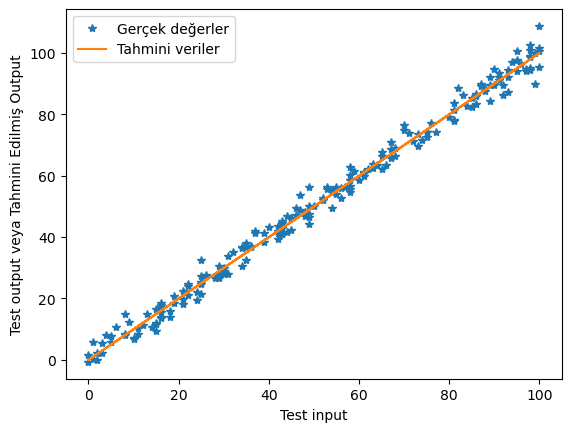

In [30]:
y_pred = test_input * parameters['m'] + parameters['c']

plt.plot(test_input, test_output, '*', label='Gerçek değerler')
plt.plot(test_input, y_pred, label='Tahmini veriler')
plt.xlabel('Test input')
plt.ylabel('Test output veya Tahmini Edilmiş Output')
plt.legend()
plt.show()


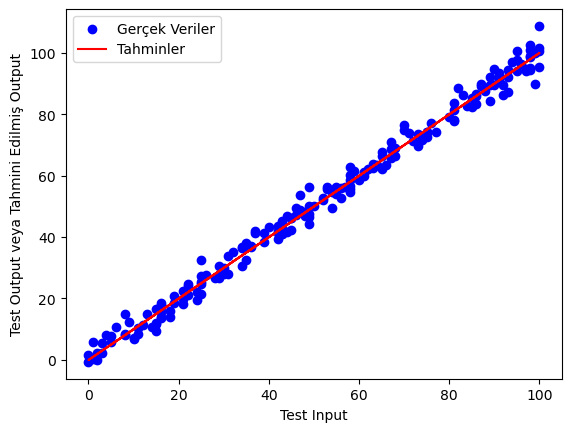

In [33]:
import matplotlib.pyplot as plt

# Eğitim sonucu öğrenilen parametreleri alın
m = parameters['m']
c = parameters['c']

# Test verileri üzerinde tahminleri yapın
y_pred = test_input * m + c

# Gerçek verileri ve tahminleri görselleştirin
plt.scatter(test_input, test_output, label='Gerçek Veriler', color='blue')
plt.plot(test_input, y_pred, label='Tahminler', color='red')
plt.xlabel('Test Input')
plt.ylabel('Test Output veya Tahmini Edilmiş Output')
plt.legend()
plt.show()
